In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')

In [52]:

df = pd.read_csv('churn.csv')

df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


##  9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

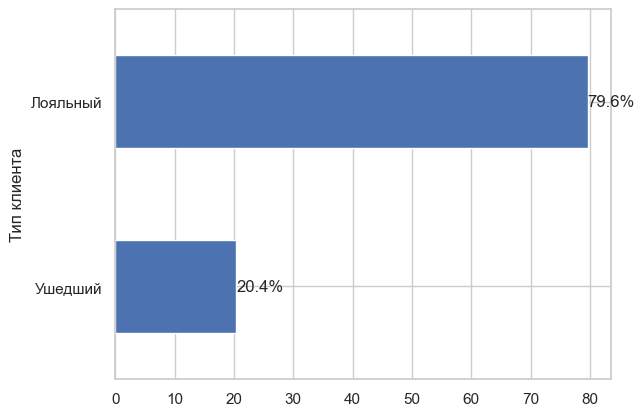

In [27]:
df['Exited_2'] = np.where(
    df['Exited'] == 0,
    'Лояльный',
    'Ушедший'
)

data = (
    df['Exited_2']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

ax = data.plot(kind='barh')
ax.set_ylabel('Тип клиента')
ax.invert_yaxis()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

## 9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

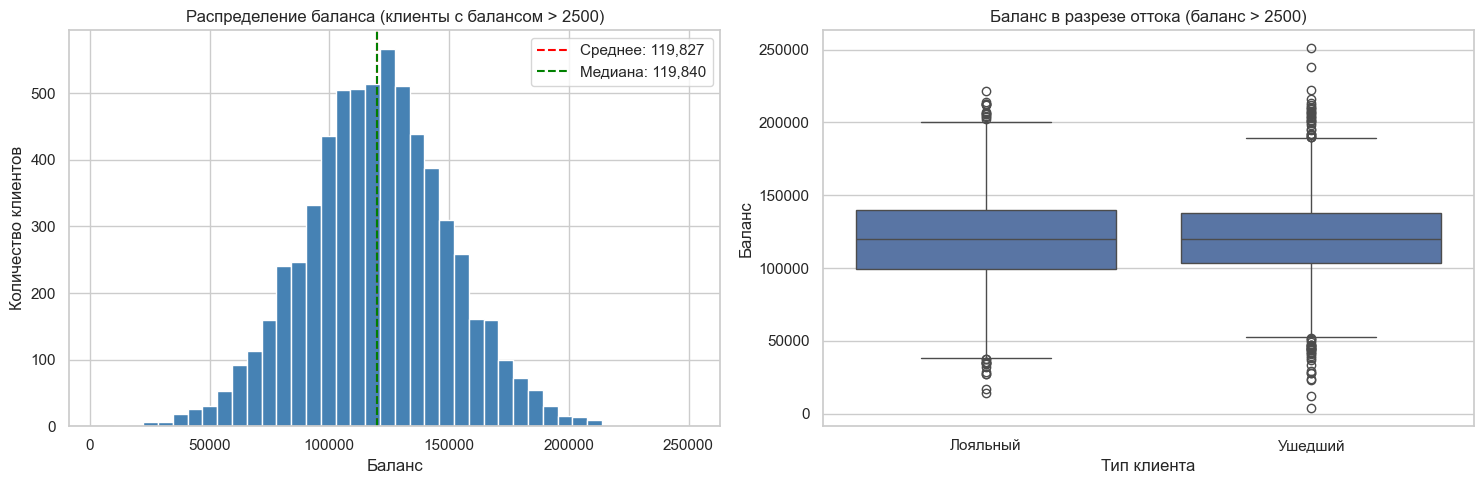

In [ ]:

df2 = df.loc[df['Balance'] > 2500].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].hist(df2['Balance'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df2['Balance'].mean(), color='red', linestyle='--',
                label=f"Среднее: {df2['Balance'].mean():,.0f}")
axes[0].axvline(df2['Balance'].median(), color='green', linestyle='--',
                label=f"Медиана: {df2['Balance'].median():,.0f}")
axes[0].set_title('Распределение баланса (клиенты с балансом > 2500)')
axes[0].set_xlabel('Баланс')
axes[0].set_ylabel('Количество клиентов')
axes[0].legend()


sns.boxplot(data=df2, x='Exited_2', y='Balance', ax=axes[1])
axes[1].set_title('Баланс в разрезе оттока (баланс > 2500)')
axes[1].set_xlabel('Тип клиента')
axes[1].set_ylabel('Баланс')

plt.tight_layout()
plt.show()

Среди клиентов с балансом > 2500 распределение баланса близко к симметричному, сильной асимметрии и выраженных выбросов нет - среднее и медиана почти совпадают. 

## 9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

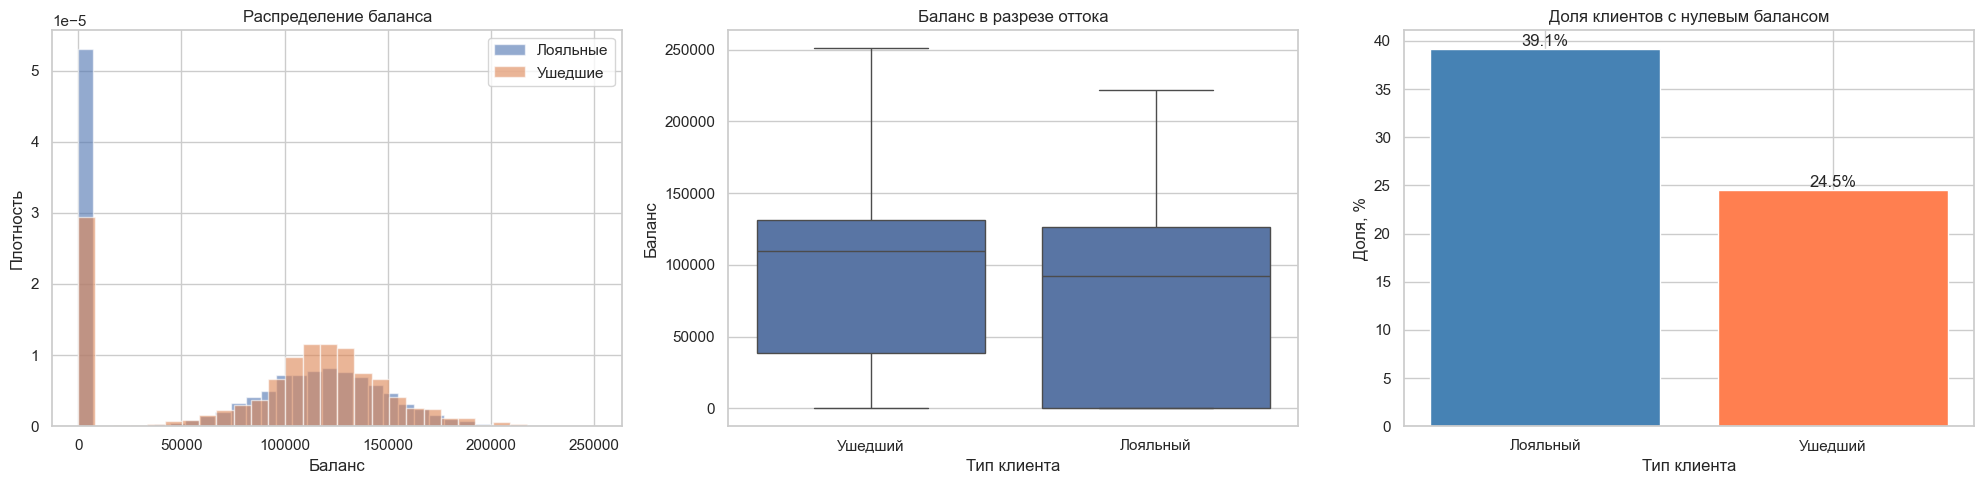

In [44]:

loyal = df['Exited_2'] == 'Лояльный'
gone  = df['Exited_2'] == 'Ушедший'

fig, axes = plt.subplots(1, 3, figsize=(20, 5))


axes[0].hist(df.loc[loyal, 'Balance'], bins=30, alpha=0.6, label='Лояльные', density=True)
axes[0].hist(df.loc[gone,  'Balance'], bins=30, alpha=0.6, label='Ушедшие',  density=True)
axes[0].set_title('Распределение баланса')
axes[0].set_xlabel('Баланс'); axes[0].set_ylabel('Плотность'); axes[0].legend()

sns.boxplot(data=df, x='Exited_2', y='Balance', ax=axes[1])
axes[1].set_title('Баланс в разрезе оттока')
axes[1].set_xlabel('Тип клиента'); axes[1].set_ylabel('Баланс')

zero_share = df.assign(is_zero=df['Balance'] == 0).groupby('Exited_2')['is_zero'].mean().mul(100)
bars = axes[2].bar(zero_share.index, zero_share.values, color=['steelblue', 'coral'])
axes[2].bar_label(bars, fmt='%.1f%%')
axes[2].set_title('Доля клиентов с нулевым балансом')
axes[2].set_xlabel('Тип клиента'); axes[2].set_ylabel('Доля, %')

plt.tight_layout()
plt.show()

У ушедших клиентов баланс действительно выше (медиана ~109 тыс. против ~92 тыс. у лояльных). Но ключевое видно на третьем графике: среди лояльных **39%** имеют нулевой баланс, а среди ушедших — только **24,5%**. То есть клиенты без накоплений почти не уходят (им нечего забирать/они мало вовлечены), а уходят как раз те, у кого на счету есть существенные суммы. Банку это важно: отток бьёт по клиентам с деньгами — их удержание приоритетно.

## 9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

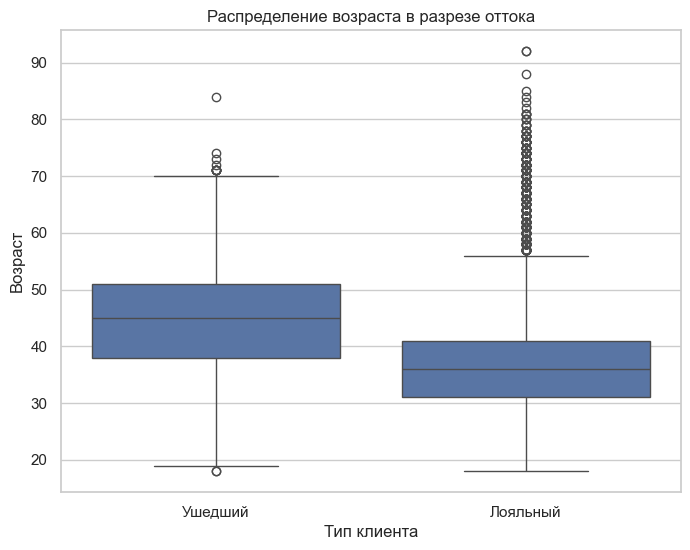

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='Exited_2', y='Age', ax=ax)

for i, g in enumerate(['Лояльный', 'Ушедший']):
    med = df.loc[df['Exited_2'] == g, 'Age'].median()


ax.set_title('Распределение возраста в разрезе оттока')
ax.set_xlabel('Тип клиента')
ax.set_ylabel('Возраст')
plt.show()

Точек-выбросов в абсолюте больше у лояльных просто потому, что эта группа в 4 раза больше (лояльных 7963, ушедших 2037). Суть, которую показывает boxplot: **уходят клиенты постарше** — медиана возраста ушедших **45 лет** против **36** у лояльных, и весь «ящик» ушедших сдвинут вверх. Банку стоит обратить внимание на возрастную группу примерно **45–60 лет** — там концентрируется отток.

## 9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.

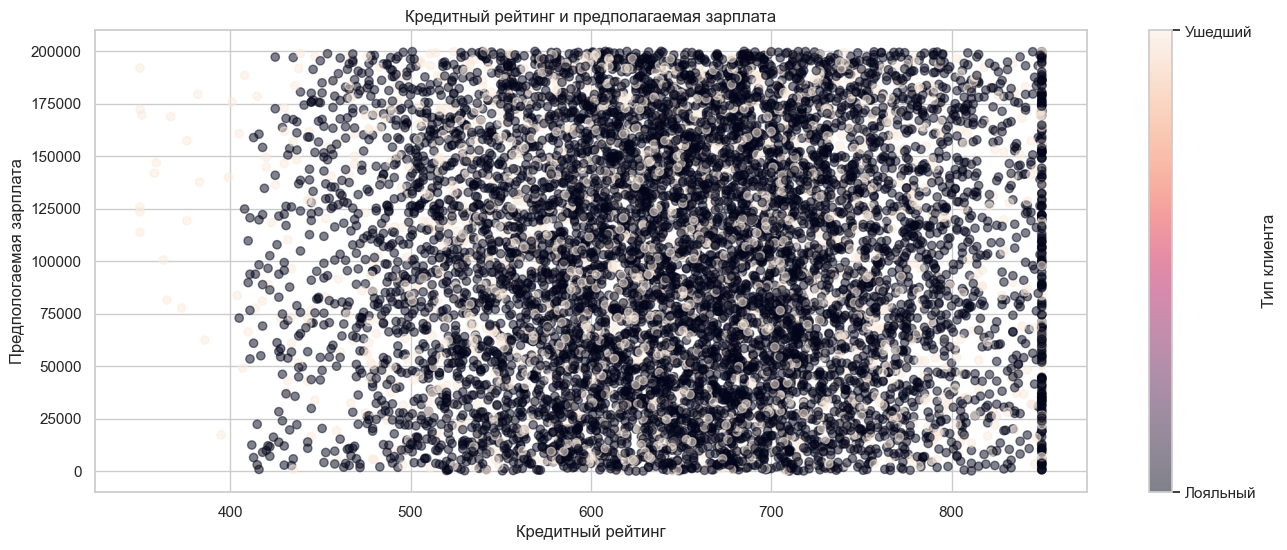

In [46]:


fig, ax = plt.subplots(figsize=(16, 6))

scatter = ax.scatter(
    df['CreditScore'],
    df['EstimatedSalary'],
    c=df['Exited'],
    alpha=0.5
)

ax.set_title('Кредитный рейтинг и предполагаемая зарплата')
ax.set_xlabel('Кредитный рейтинг')
ax.set_ylabel('Предпологаемая зарплата')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Тип клиента')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Лояльный', 'Ушедший'])

plt.show()

Связи нет

## 9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

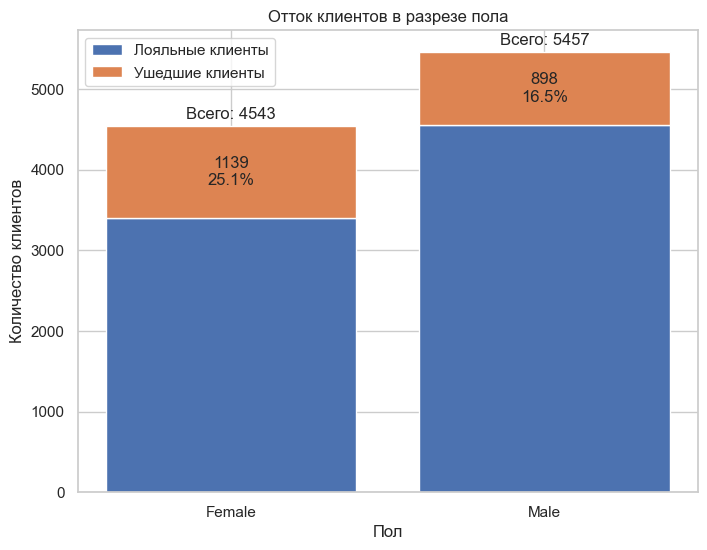

In [ ]:
import matplotlib.pyplot as plt


result = (
    df.assign(
        CustomerId_exited=df['CustomerId'].where(df['Exited_2'] == 'Ушедший')
    )
    .groupby('Gender')
    .agg(
        Количество_всего=('CustomerId', 'nunique'),
        Количество_ушедших=('CustomerId_exited', 'nunique')
    )
    .reset_index()
)

result['Количество_лояльных'] = (
    result['Количество_всего'] - result['Количество_ушедших']
)

result['Доля_ушедших_%'] = (
    result['Количество_ушедших'] / result['Количество_всего'] * 100
).round(1)


fig, ax = plt.subplots(figsize=(8, 6))

bars_loyal = ax.bar(
    result['Gender'],
    result['Количество_лояльных'],
    label='Лояльные клиенты'
)

bars_exited = ax.bar(
    result['Gender'],
    result['Количество_ушедших'],
    bottom=result['Количество_лояльных'],
    label='Ушедшие клиенты'
)


ax.bar_label(
    bars_exited,
    labels=[
        f"{row['Количество_ушедших']}\n{row['Доля_ушедших_%']}%"
        for _, row in result.iterrows()
    ],
    label_type='center'
)

ax.bar_label(
    bars_exited,
    labels=[
        f"Всего: {row['Количество_всего']}"
        for _, row in result.iterrows()
    ],
    label_type='edge',
    padding=3
)


ax.set_title('Отток клиентов в разрезе пола')
ax.set_xlabel('Пол')
ax.set_ylabel('Количество клиентов')
ax.legend()

plt.show()

Чаще уходят женщины

## 9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.

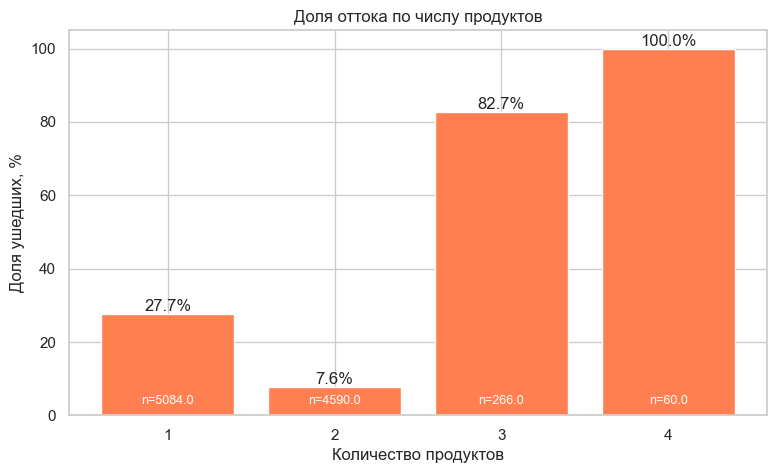

In [ ]:

prod = (
    df.groupby('NumOfProducts')
      .agg(Всего=('Exited', 'size'), Доля_оттока=('Exited', 'mean'))
      .reset_index()
)
prod['Доля_оттока'] = (prod['Доля_оттока'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(prod['NumOfProducts'].astype(str), prod['Доля_оттока'], color='coral')
ax.bar_label(bars, fmt='%.1f%%')

for i, row in prod.iterrows():
    ax.text(i, 3, f"n={row['Всего']}", ha='center', color='white', fontsize=9)

ax.set_title('Доля оттока по числу продуктов')
ax.set_xlabel('Количество продуктов')
ax.set_ylabel('Доля ушедших, %')
ax.set_ylim(0, 105)
plt.show()

Минимальный отток — у клиентов с 2 продуктами. У клиентов с 1 продуктом отток заметно выше, чем у 2 (поэтому «чем больше — тем хуже» не работает на левом краю). А вот 3–4 продукта — зона катастрофического оттока. Оговорка: в группах 3 и 4 продукта всего 266 и 60 клиентов, поэтому выводы по ним менее надёжны, но сигнал тревожный.

## 9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?

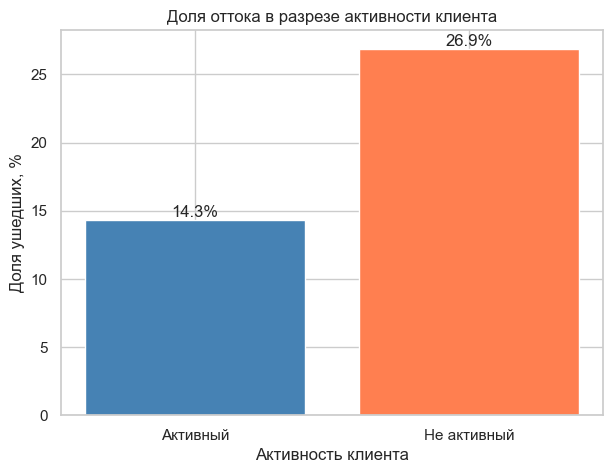

In [ ]:
df['Activ_user'] = np.where(df['IsActiveMember'] == 0, 'Не активный', 'Активный')

act = (
    df.groupby('Activ_user')
      .agg(Всего=('Exited', 'size'), Доля_оттока=('Exited', 'mean'))
      .reset_index()
)
act['Доля_оттока'] = (act['Доля_оттока'] * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(act['Activ_user'], act['Доля_оттока'], color=['steelblue', 'coral'])
ax.bar_label(bars, fmt='%.1f%%')

ax.set_title('Доля оттока в разрезе активности клиента')
ax.set_xlabel('Активность клиента')
ax.set_ylabel('Доля ушедших, %')
plt.show()

Доля оттока среди неактивных клиентов — **26,9%**, среди активных — **14,3%**, то есть почти вдвое выше. Что предложить банку для снижения оттока среди неактивных: реактивационные коммуникации (персональные предложения, напоминания), бонусы за возобновление активности, выявление «спящих» клиентов на ранней стадии и адресные кампании по их вовлечению.

## 9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.

In [ ]:
result = (
    df.assign(
        CustomerId_exited=df['CustomerId'].where(df['Exited_2'] == 'Ушедший')
    )
    .groupby('Geography')
    .agg(
        Количество_всего=('CustomerId', 'nunique'),
        Количество_ушедших=('CustomerId_exited', 'nunique')
    )
    .reset_index()
)

result['Доля_ушедших_%'] = (
    result['Количество_ушедших'] / result['Количество_всего'] * 100
).round(2)

result.sort_values('Доля_ушедших_%', ascending=False)

import plotly.express as px

fig = px.choropleth(
    result,
    locations='Geography',
    locationmode='country names',
    color='Доля_ушедших_%',
    hover_name='Geography',
    hover_data={
        'Количество_всего': True,
        'Количество_ушедших': True,
        'Доля_ушедших_%': True
    },
    title='Доля ушедших клиентов по странам',
    color_continuous_scale='Reds'
)

fig.show()

/var/folders/ls/d6mbmny12hb59h29c1bx9rsm0000gn/T/ipykernel_7728/7221315.py:21: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


Самая высокая доля оттока — в **Германии: 32,4%**, тогда как во Франции и Испании она примерно вдвое ниже (16,2% и 16,7%). С чем может быть связано: возможно, более конкурентный банковский рынок в Германии, менее привлекательные условия именно этого банка для немецких клиентов, или особенности продукта/сервиса в регионе. Точную причину по этим данным установить нельзя — нужен дополнительный анализ (продукты, тарифы, сервис по странам).

In [40]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

df['CreditScoreCat'] = df['CreditScore'].apply(get_credit_score_cat)

df['CreditScoreCat'].value_counts()

df['CreditScoreCat'].value_counts(normalize=True) * 100

df['CreditScoreCat'] = df['CreditScore'].apply(get_credit_score_cat)

df[['CreditScore', 'CreditScoreCat']].head(10)


,CreditScore,CreditScoreCat
0,619,Fair
1,608,Fair
2,502,Poor
3,699,Good
4,850,Excellent
5,645,Fair
6,822,Excellent
7,376,Very_Poor
8,501,Poor
9,684,Good


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

credit_score_order = [
    'Deep',
    'Very_Poor',
    'Poor',
    'Fair',
    'Good',
    'Excellent',
    'Top'
]

df['CreditScoreCat'] = pd.Categorical(
    df['CreditScoreCat'],
    categories=credit_score_order,
    ordered=True
)


pivot_table = df.pivot_table(
    index='CreditScoreCat',
    columns='Tenure',
    values='Exited',
    aggfunc='mean'
)

pivot_table_percent = (pivot_table * 100).round(1)

pivot_table_percent

Tenure,0,1,2,3,4,5,6,7,8,9,10
CreditScoreCat,,,,,,,,,,,
Very_Poor,44.4,25.4,15.2,28.6,29.3,14.9,22.5,20.6,25.4,23.0,33.3
Poor,22.6,25.9,21.2,21.2,23.3,19.9,18.0,15.1,21.5,25.1,16.9
Fair,21.7,21.6,21.3,21.6,19.7,20.7,23.6,17.1,20.9,19.0,20.5
Good,20.4,20.4,18.7,20.6,19.5,21.4,18.3,19.2,15.2,19.5,19.8
Excellent,27.5,20.8,13.7,16.8,13.2,23.3,24.1,12.8,19.6,27.1,25.5


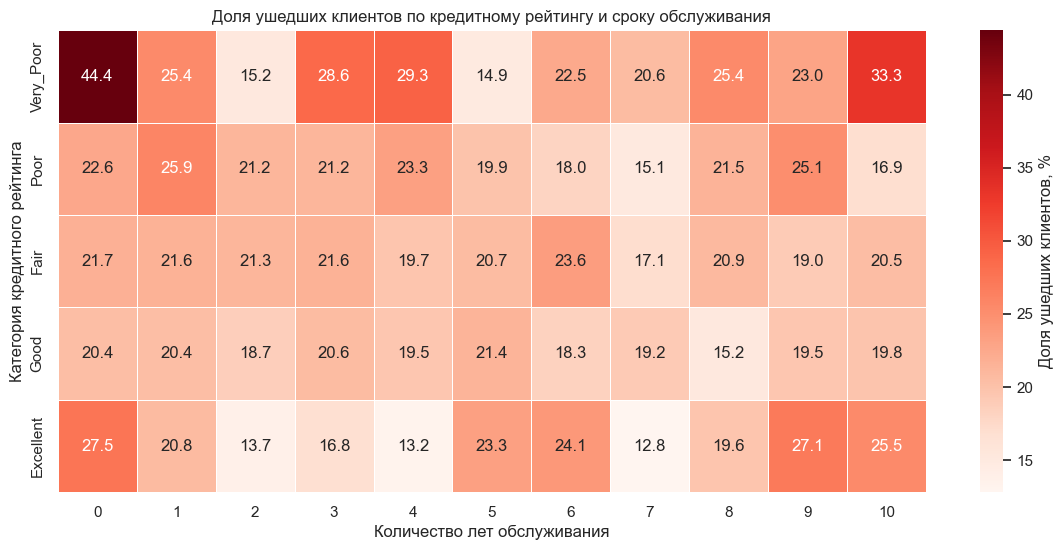

In [42]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot_table_percent,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Доля ушедших клиентов, %'}
)

plt.title('Доля ушедших клиентов по кредитному рейтингу и сроку обслуживания')
plt.xlabel('Количество лет обслуживания')
plt.ylabel('Категория кредитного рейтинга')

plt.show()

In [43]:
max_churn = pivot_table_percent.stack().sort_values(ascending=False)
max_churn.head(10)

CreditScoreCat  Tenure
Very_Poor       0         44.4
                10        33.3
                4         29.3
                3         28.6
Excellent       0         27.5
                9         27.1
Poor            1         25.9
Excellent       10        25.5
Very_Poor       8         25.4
                1         25.4
dtype: float64

По сочетанию «категория кредитного рейтинга × срок обслуживания» доля оттока распределена довольно равномерно — выраженных «горячих» зон нет. Это значит, что ни кредитный рейтинг, ни срок обслуживания сами по себе (и в комбинации) не являются сильными драйверами оттока. 